In [1]:
import os
import pathlib
from collections import defaultdict

import json
from typing import List, Literal

from tqdm import trange

import numpy as np
import pandas as pd

import scanpy as sc
import anndata

import torch
import torch.nn as nn

from scipy import stats

import matplotlib.pyplot as plt
import seaborn as sns

import sys
sclembas = '/home/hmbaghda/Projects/scLEMBAS'
sys.path.insert(1, os.path.join(sclembas))
from scLEMBAS import io
from scLEMBAS import preprocess as pp 
from scLEMBAS.model.train import TrainSC
from scLEMBAS.model.scl import SignalingModel
from scLEMBAS.predict import get_prediction
from scLEMBAS.metrics import distances 


sys.path.insert(1, '../../.')
from McCauley_utils import initialize_mod_and_trainer, all_data

sys.path.insert(1, '../../../.') 
from notebook_utils import get_split

sys.path.insert(1, './.')
from pruning_utils import load_model, get_edge_weights


/orcd/pool/005/hmbaghda/miniforge3/envs/scLEMBAS_v2/lib/python3.11/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator PLSRegression from version 1.7.2 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/orcd/pool/005/hmbaghda/miniforge3/envs/scLEMBAS_v2/lib/python3.11/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator OneHotEncoder from version 1.7.2 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [2]:
seed = 888
data_path = '/home/hmbaghda/orcd/pool/scLEMBAS/analysis'
author = 'McCauley'

n_cores = 30
os.environ["OMP_NUM_THREADS"] = str(1)
os.environ["MKL_NUM_THREADS"] = str(1)
os.environ["OPENBLAS_NUM_THREADS"] = str(1)
os.environ["VECLIB_MAXIMUM_THREADS"] = str(1)
os.environ["NUMEXPR_NUM_THREADS"] = str(1)


In [3]:
(sn_ppis, tf_adata, adata, expr, source_label, target_label, weight_label, 
 stimulation_label, inhibition_label, cat_col, pert_col, ctrl_pert) = all_data

# Get model results

In [4]:
bn_weight_l2 = 0#1e-1 # 1e-4 # 1e-7
bn_weight_l1 = 1e-3 #0

In [5]:
learned_weights = []
train_stats = []
eval_stats = []
loss_res = defaultdict(list)

fn = os.path.join(data_path, 'processed', '{}_pruning_res_all.pickle'.format(author))

if not os.path.isfile(fn):
    for fold in range(5):

        split = get_split(fold = fold, author = author)

        test_conds = split['test_conds']
        train_barcodes = split['train_barcodes']
        test_barcodes = split['test_barcodes']

        ctrl_conds = sorted(set([tc.split('^')[0] + '^' + ctrl_pert for tc in test_conds]))
        ctrl_mask = tf_adata.obs.loc[train_barcodes, 'condition'].isin(ctrl_conds).values
        ctrl_cells = list(np.array(train_barcodes)[ctrl_mask])


        for ensemble_idx in trange(5):
    #         try:

            # load
            mod, trainer, train_stats_df, eval_df = load_model(fold = fold, ensemble_idx = ensemble_idx, 
                          bn_weight_l2 = bn_weight_l2, bn_weight_l1 = bn_weight_l1,
                          from_trainer = False)

            # RESULTS
            stochastic_edge_weights, real_edge_weights = get_edge_weights(mod)

            tf_adata_predicted = get_prediction(
                mod = mod,
                train_cells = train_barcodes,
                test_cells = test_barcodes, 
                tf_adata = tf_adata,
                cat_col = cat_col,
                pert_col = pert_col,
                ctrl_pert = ctrl_pert, 
                counterfactual = 'perturbation', # counterfactual from tests
                cat_counterfactual_map = None,
                remove_type = 'none',
                return_bias = False, 
                max_cells = int(5e3), 
                return_full = False, 
                stim_label_map = None, # special use case for Kang
            )
            emd_loss = distances.get_EMD_loss(tf_adata, tf_adata_predicted)['Mean EMD Loss']
            loss_res['loss'].append(emd_loss)
            loss_res['fold'].append(fold)
            loss_res['ensemble_idx'].append(ensemble_idx)


            # formatting
            learned_vals = pd.DataFrame(data= {
                'weights': np.concatenate([stochastic_edge_weights.numpy(), real_edge_weights.numpy()]), 
                'edge_type': ['random']*stochastic_edge_weights.size()[0] + ['real']*real_edge_weights.size()[0]
            })

            for df in [train_stats_df, eval_df, learned_vals]:
                df['fold'] = fold
                df['ensemble_idx'] = ensemble_idx

            # storing
            learned_weights.append(learned_vals)
            train_stats.append(train_stats_df)
            eval_stats.append(eval_df)
    #             mod_dict['fold{}_ensemble{}'.format(fold, ensemble_idx)] = mod
            del mod, trainer
    #         except:
    #             pass

    learned_weights = pd.concat(learned_weights)

    train_stats_df = pd.concat(train_stats)
    eval_stats_df = pd.concat(eval_stats)
    lr_stochastic = pd.DataFrame(loss_res)


    all_results = {
        "learned_weights": learned_weights,
        "train_stats_df": train_stats_df,
        "eval_stats_df": eval_stats_df,
        "lr_stochastic": lr_stochastic,
    }

    io.write_pickled_object(all_results, fn)


else:
    all_results = io.read_pickled_object(fn)

    learned_weights = all_results["learned_weights"]
    train_stats_df = all_results["train_stats_df"]
    eval_stats_df = all_results["eval_stats_df"]
    lr_stochastic = all_results["lr_stochastic"]

    learned_weights.edge_type = pd.Categorical(learned_weights.edge_type, 
                                              categories = ['real', 'random'], 
                                               ordered = True
                                              )

    
learned_weights.edge_type = pd.Categorical(learned_weights.edge_type, 
                                          categories = ['real', 'random'], 
                                           ordered = True
                                          )

# CDF visualization

In [6]:
sns.set_context(
    "paper",
    rc={
        "axes.labelsize": 15,
        "axes.titlesize": 16,
        "legend.fontsize": 12,
        "xtick.labelsize": 14,
        "ytick.labelsize": 14,
    }
)

In [7]:
def cohens_d_paired(a, b):
    """
    Paired Cohen's d.
    Positive d => mean(a) > mean(b)
    """
    diff = a - b
    return diff.mean() / diff.std(ddof=1)

def cohens_d(x, y):
    x = np.asarray(x)
    y = np.asarray(y)
    
    nx = len(x)
    ny = len(y)
    
    mean_x = x.mean()
    mean_y = y.mean()
    
    var_x = x.var(ddof=1)
    var_y = y.var(ddof=1)
    
    pooled_std = np.sqrt(((nx - 1) * var_x + (ny - 1) * var_y) / (nx + ny - 2))
    
    return (mean_x - mean_y) / pooled_std


def compute_cdf(x, log_transform: bool = False):
    x = np.asarray(x)
    if log_transform: 
        x = np.log(x)
    x_sorted = np.sort(x)
    y = np.arange(1, len(x_sorted) + 1, dtype=float) / len(x_sorted)
    return x_sorted, y

log_cdf_visual = True
weights_percentile_min = 0.75 # helps to zoom in on visual -- set to None or 0 if want to visualize everything
ymin_scaler = 1.2 # 1 to get the corresponding 75th percentile value


For CDF visualization, ensembles are pooled across fold. For residual statistics, CDFs are retained at the individual level.

/orcd/pool/005/hmbaghda/miniforge3/envs/scLEMBAS_v2/lib/python3.11/site-packages/seaborn/categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)
/orcd/pool/005/hmbaghda/miniforge3/envs/scLEMBAS_v2/lib/python3.11/site-packages/seaborn/categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)


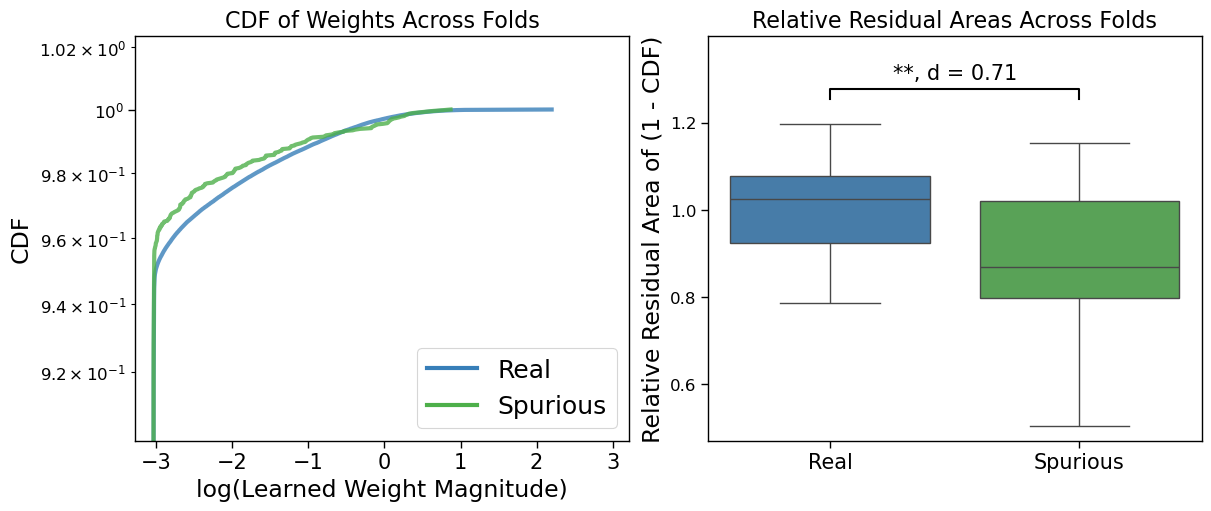

In [8]:
# helper used by the significance bracket
def _sig_stars(p):
    if p < 1e-4:  return "****"
    if p < 1e-3:  return "***"
    if p < 1e-2:  return "**"
    if p < 5e-2:  return "*"
    return "ns"

# -------------------- SETUP --------------------
real_color  = sns.color_palette('Set1')[1]   # blue  (matches reference "actual")
stoch_color = sns.color_palette('Set1')[2]   # green (new baseline: not orange/purple/gray)

real_mask = (learned_weights.edge_type == 'real')

with sns.plotting_context(
    "paper",
    rc={
        "axes.labelsize": 17,
        "axes.titlesize": 16,
        "legend.fontsize": 18,
        "xtick.labelsize": 15,
        "ytick.labelsize": 12,
    }
):

    fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12, 5), constrained_layout=True)

    # -------------------- CDF PANEL --------------------
    j = 0

    # CDF visualization: all
    x_stoch, y_stoch = compute_cdf(learned_weights[~real_mask].weights.values, log_transform=log_cdf_visual)
    x_real,  y_real  = compute_cdf(learned_weights[real_mask].weights.values,  log_transform=log_cdf_visual)
    ax[j].plot(x_real,  y_real,  color=real_color,  alpha=0.8, linewidth=3, zorder=2, label="Real")
    ax[j].plot(x_stoch, y_stoch, color=stoch_color, alpha=0.8, linewidth=3, zorder=2, label="Spurious")

    if weights_percentile_min is not None and weights_percentile_min > 0:
        weight_vals = np.log(learned_weights.weights) if log_cdf_visual else learned_weights.weights
        percentile_val = weight_vals.quantile(weights_percentile_min)

        _, xmax = ax[j].get_xlim()
        _, ymax = ax[j].get_ylim()

        xmin = percentile_val

        x_sorted, y_filtered = compute_cdf(learned_weights.weights.values, log_transform=log_cdf_visual)
        ymin = y_filtered[np.searchsorted(x_sorted, percentile_val, side='left')] * ymin_scaler

        ax[j].set_ylim(ymin, ymax * 0.975)
        ax[j].set_xlim(xmin, xmax * 0.975)

    xlabel = "Learned Weight Magnitude" if not log_cdf_visual else "log(Learned Weight Magnitude)"
    ax[j].set_xlabel(xlabel)
    ax[j].set_ylabel("CDF")
    ax[j].set_title("CDF of Weights Across Folds")
    ax[j].set_yscale('log')

    # clean legend (manual to avoid duplicates)
    handles = [
        plt.Line2D([0], [0], linewidth = 3, color=real_color,  label="Real"),
        plt.Line2D([0], [0], linewidth = 3, color=stoch_color, label="Spurious"),
    ]
    

    ax[j].legend(handles=handles, loc='lower right')

    # -------------------- BOXPLOT PANEL --------------------
    j = 1

    residuals_stochastic = []
    residuals_real = []
    # residual statistics
    for fold in range(5):
        fold_mask = (learned_weights.fold == fold)
        for ensemble_idx in range(5):
            ensemble_mask = (learned_weights.ensemble_idx == ensemble_idx)

            x_stoch, y_stoch = compute_cdf(
                learned_weights[~real_mask & fold_mask & ensemble_mask].weights.values, log_transform=False
            )
            x_real, y_real = compute_cdf(
                learned_weights[real_mask & fold_mask & ensemble_mask].weights.values, log_transform=False
            )

            # residual areas
            area_stoc = np.trapz(1 - y_stoch, x_stoch)
            area_real = np.trapz(1 - y_real, x_real)

            residuals_stochastic.append(area_stoc)
            residuals_real.append(area_real)

    # same if run on normalized or not
    a = np.array(residuals_real)
    b = np.array(residuals_stochastic)
    cd = cohens_d_paired(a, b)
    pval = stats.wilcoxon(a, b, alternative='greater').pvalue

    mean_real = np.mean(residuals_real)

    df_box = pd.DataFrame({
        "value": np.concatenate([
            np.array(residuals_real) / mean_real,
            np.array(residuals_stochastic) / mean_real,
        ]),
        "type": ["Real"] * len(residuals_real) +
                ["Spurious"] * len(residuals_stochastic)
    })

    sns.boxplot(
        data=df_box,
        x="type",
        y="value",
        palette={"Spurious": stoch_color, "Real": real_color},
        ax=ax[j],
    )

    ax[j].set_ylabel("Relative Residual Area of (1 - CDF)")
    ax[j].set_xlabel("")
    ax[j].set_title("Relative Residual Areas Across Folds")

    # --- significance bracket: stars + Cohen's d on the same line ---
    y_lo, y_hi = ax[j].get_ylim()
    span = y_hi - y_lo
    bar_y = y_hi + span * 0.06        # bracket sits above the boxes
    tick  = span * 0.03               # end-cap drop
    bx1, bx2 = 0, 1                   # box x-positions (Real, Spurious)

    ax[j].plot(
        [bx1, bx1, bx2, bx2],
        [bar_y - tick, bar_y, bar_y, bar_y - tick],
        lw=1.5, c="black", clip_on=False,
    )
    ax[j].text(
        (bx1 + bx2) / 2.0, bar_y + span * 0.015,
        "{}, d = {:.2f}".format(_sig_stars(pval), cd),
        ha="center", va="bottom", fontsize=15,
    )
    ax[j].set_ylim(y_lo, bar_y + span * 0.16)

    # -------------------- SAVE --------------------
    for ext in ['svg', 'png']:
        fig.savefig(
            os.path.join(data_path, 'figures', '{}_self_pruning_cdf.{}'.format(author, ext)),
            dpi=600 if ext == "png" else None,   # dpi matters for raster, not svg
            bbox_inches="tight",
            transparent=True,
        )

    plt.show()

In [16]:
weights_percentile_min = None #None # helps to zoom in on visual -- set to None or 0 if want to visualize everything
ymin_scaler = 1 # 1 to get the corresponding 75th percentile value

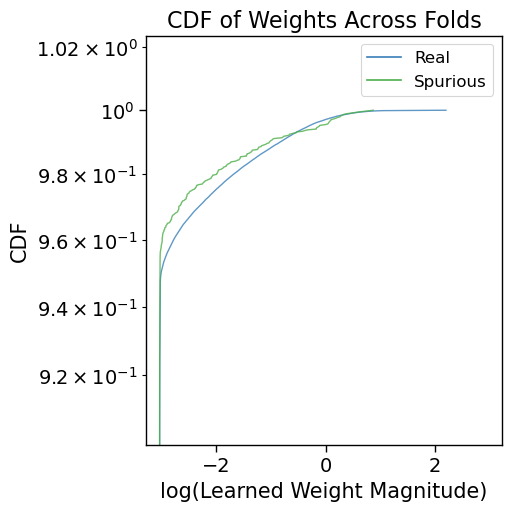

In [49]:
# -------------------- SETUP --------------------
n_cols = 1
fig, ax = plt.subplots(nrows=1, ncols=n_cols, figsize=(5, 5), constrained_layout=True)
if n_cols == 1:
    ax = [ax]

stoch_color = sns.color_palette('Set1')[2]  #"#999999" #sns.color_palette('Set1')[4]
real_color = sns.color_palette('Set1')[1]

real_mask = (learned_weights.edge_type == 'real')

# -------------------- CDF PANEL --------------------
j = 0

# # CDF visualization: per-model
# for fold in range(5):
#     fold_mask = (learned_weights.fold == fold)
#     for ensemble_idx in range(5):
#         ensemble_mask = (learned_weights.ensemble_idx == ensemble_idx)
        
#         x_stoch, y_stoch = compute_cdf(learned_weights[~real_mask & fold_mask & ensemble_mask].weights.values, 
#                                        log_transform = log_cdf_visual)
#         x_real, y_real = compute_cdf(learned_weights[real_mask & fold_mask & ensemble_mask].weights.values, 
#                                      log_transform = log_cdf_visual)
        
#         ax[j].plot(x_real, y_real, color=real_color, alpha=0.3, linewidth=1, zorder=1)
#         ax[j].plot(x_stoch, y_stoch, color=stoch_color, alpha=0.3, linewidth=1, zorder=1)

# # CDF visualization: per-fold
# for fold in range(5):
#     fold_mask = (learned_weights.fold == fold)

#     x_stoch, y_stoch = compute_cdf(learned_weights[fold_mask & ~real_mask].weights.values, log_transform = log_cdf_visual)
#     x_real, y_real = compute_cdf(learned_weights[fold_mask & real_mask].weights.values, log_transform = log_cdf_visual)

#     ax[j].plot(x_real, y_real, color=real_color, alpha=0.3, linewidth=1, zorder=1)
#     ax[j].plot(x_stoch, y_stoch, color=stoch_color, alpha=0.3, linewidth=1, zorder=1)

# CDF visualization: all
x_stoch, y_stoch = compute_cdf(learned_weights[~real_mask].weights.values, log_transform = log_cdf_visual)
x_real, y_real = compute_cdf(learned_weights[real_mask].weights.values, log_transform = log_cdf_visual)
ax[j].plot(x_real, y_real, color=real_color, alpha=0.8, linewidth=1, zorder=2, label="Real")
ax[j].plot(x_stoch, y_stoch, color=stoch_color, alpha=0.8, linewidth=1, zorder=2, label="Spurious")

# zoom in on relevant regime
# ax[j].set_ylim(0.9, 1.01)
# ax[j].set_xlim(-3.2, 3)

if weights_percentile_min is not None and weights_percentile_min > 0:
    weight_vals = np.log(learned_weights.weights) if log_cdf_visual else learned_weights.weights
    percentile_val = weight_vals.quantile(weights_percentile_min)
    
    _, xmax = ax[j].get_xlim()
    _, ymax = ax[j].get_ylim()
    
    xmin = percentile_val
    
    x_sorted, y_filtered = compute_cdf(learned_weights.weights.values,log_transform=log_cdf_visual)
    ymin = y_filtered[np.searchsorted(x_sorted, percentile_val, side='left')] * ymin_scaler
    
    ax[j].set_ylim(ymin, ymax*0.975)
    ax[j].set_xlim(xmin, xmax*0.975)


xlabel = "Learned Weight Magnitude" if not log_cdf_visual else "log(Learned Weight Magnitude)"
ax[j].set_xlabel(xlabel)
ax[j].set_ylabel("CDF")
ax[j].set_title("CDF of Weights Across Folds")
ax[j].set_yscale('log')

# clean legend (manual to avoid duplicates)
handles = [
    plt.Line2D([0], [0], color=real_color, label="Real"),
    plt.Line2D([0], [0], color=stoch_color, label="Spurious")
]
ax[j].legend(handles=handles)


plt.show()


# Check Loss Results and Training Curves

In [52]:
lr_no_stochastic = pd.read_csv(os.path.join(data_path, 'processed', '{}_scLEMBAS_model_losses.csv'.format(author)), 
                              index_col = 0)

mask = (
    (lr_no_stochastic.loss_type == 'EMD') &
    (lr_no_stochastic.remove_type == 'none') &
    (lr_no_stochastic.model_type == 'actual') &
    (lr_no_stochastic.space == 'feature'))
lr_no_stochastic = lr_no_stochastic[mask].copy()

lr_stochastic['model_type'] = 'scLEMBAS\n(standard training)'
lr_no_stochastic['model_type'] = 'scLEMBAS\n(trained with\nspurious edges)'
loss_res = pd.concat([lr_no_stochastic, lr_stochastic])
loss_res['model_type'] = pd.Categorical(
    loss_res['model_type'], 
    categories = ['scLEMBAS\n(standard training)', 'scLEMBAS\n(trained with\nspurious edges)'], 
    ordered = True
)

In [53]:
# identify all-zero columns (across all folds + ensembles)
loss_cols_main = [
    'train_loss_prediction', 'sign_reg_loss',
    'stability_reg_loss', 'uniform_reg_loss', 'input_param_reg_loss',
    'sn_param_reg_tot_loss', 'output_param_reg_tot_loss', 'vae_param_reg_loss',
    'global_bias_kl_divergence', 'contrastive_loss_total'
]
all_loss_cols = (
    loss_cols_main
    + ['total_train_loss_no_adverserial']
    + [
        'sn_param_reg_tot_loss',
        'sn_param_reg_weights_L2_loss',
        'sn_param_reg_weights_L1_loss',
        'sn_param_reg_weights_kl_divergence',
        'sn_param_reg_global_bias_L2_loss',
        'sn_param_reg_global_bias_L1_loss',
        'sn_param_reg_cat_bias_L2_loss',
        'sn_param_reg_cat_bias_L1_loss',
        'sn_param_reg_cat_bias_pert'
    ]
)

zero_cols = {
    col for col in all_loss_cols
    if col in train_stats_df.columns and np.all(train_stats_df[col].values == 0)
}

for col in ['sign_reg_loss']:
    train_stats_df[col] = train_stats_df[col].mask(
        (train_stats_df[col] == 0), 
        np.nan
    )
    
loss_map = {
    'train_loss_prediction': 'Prediction',
    'sign_reg_loss': 'Sign Reg.',
    'stability_reg_loss': 'Spectral Reg.',
    'uniform_reg_loss': 'Uniform Reg.',
    'contrastive_loss_total': 'Contrastive Reg.',
    'input_param_reg_loss': 'Input Param Reg.',
    'sn_param_reg_tot_loss': 'Signaling Network Param Reg.',
    'output_param_reg_tot_loss': 'Output Param Reg.',
    'vae_param_reg_loss': 'VAE Param Reg.',
    'global_bias_kl_divergence': r'$b_g$' + ' KL Div.',
    'total_train_loss_no_adverserial': 'Total (No Adversarial)'
}

def compute_mean(df, cols):
    return df.groupby("epoch")[cols].mean().reset_index()

eval_df = eval_stats_df.copy()

Panel 1 wilcoxon p-val: 7.46E-01


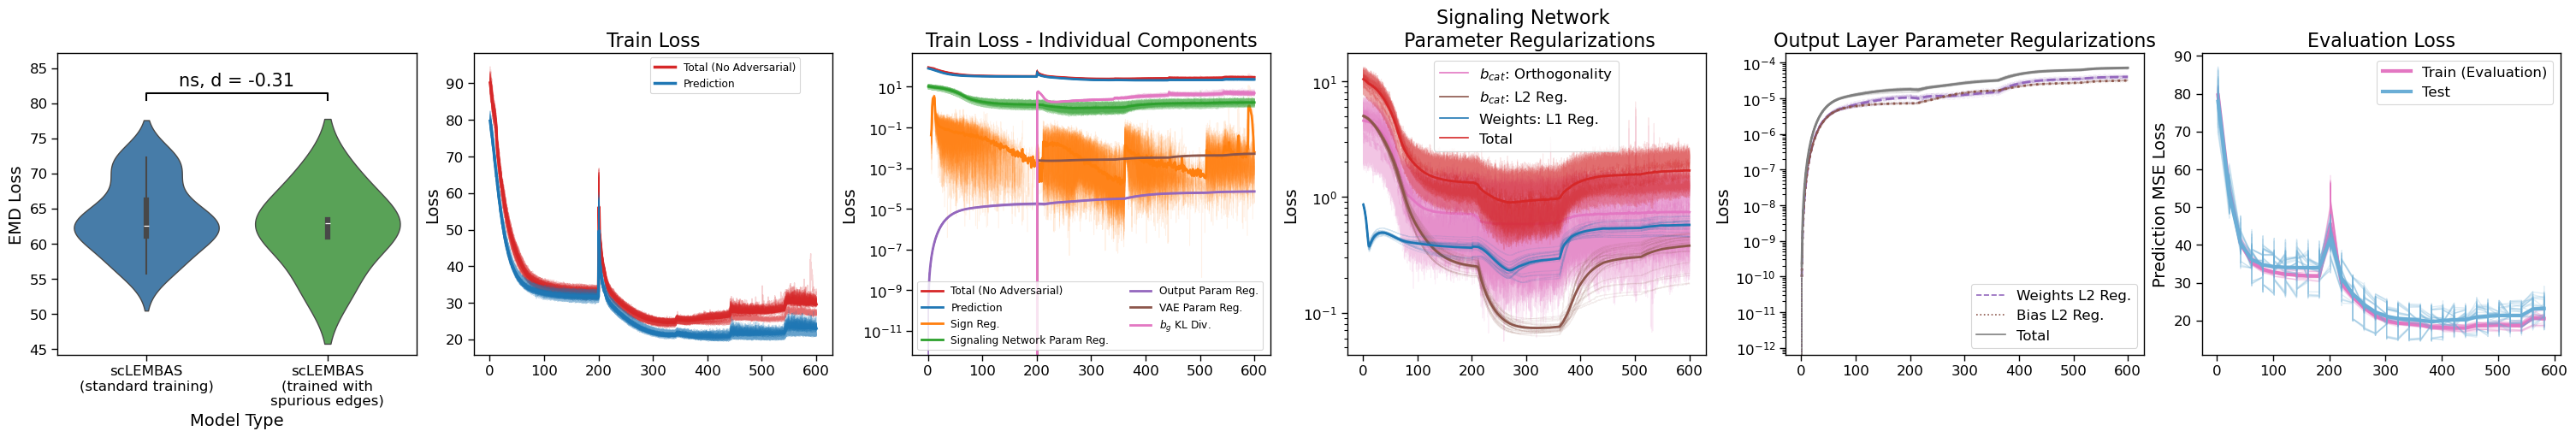

In [54]:
from matplotlib.lines import Line2D

with sns.plotting_context(
    "paper", font_scale=1.1,
    rc={
        "axes.labelsize": 14,
        "axes.titlesize": 16,
        "legend.fontsize": 12,
        "xtick.labelsize": 12,
        "ytick.labelsize": 12,
    }
):

    fig, ax = plt.subplots(nrows=1, ncols=6, figsize=(30, 5), constrained_layout=True)

    # =======================
    # 0. Loss comparison  (unchanged)
    # =======================
    j = 0
    a = lr_no_stochastic['loss'].values
    b = lr_stochastic['loss'].values
    cd = cohens_d(a, b)
    pval = stats.mannwhitneyu(a, b, alternative='two-sided').pvalue
    
    print('Panel 1 wilcoxon p-val: {:.2E}'.format(pval))
    sns.violinplot(data=loss_res, x='model_type', hue='model_type',
                   palette=[sns.color_palette('Set1')[1], sns.color_palette('Set1')[2]], #"#999999"],
                   y='loss', ax=ax[j])
    ax[j].set_xlabel('Model Type')
    ax[j].set_ylabel('EMD Loss')
    ax[j].tick_params(axis='x', labelsize=12)

    # --- significance bracket: stars + Cohen's d on the same line ---
    # anchor to the current top limit (includes the violin KDE tails)
    # so the bracket clears the violins
    y_lo, y_hi = ax[j].get_ylim()
    span = y_hi - y_lo
    bar_y = y_hi + span * 0.06        # bracket sits above the violins
    tick  = span * 0.03               # end-cap drop
    vx1, vx2 = 0, 1                   # violin x-positions
    ax[j].plot(
        [vx1, vx1, vx2, vx2],
        [bar_y - tick, bar_y, bar_y, bar_y - tick],
        lw=1.5, c="black", clip_on=False,
    )
    ax[j].text(
        (vx1 + vx2) / 2.0, bar_y + span * 0.015,
        "{}, d = {:.2f}".format(_sig_stars(pval), cd),
        ha="center", va="bottom", fontsize=15,
    )
    # extend the axis so the bracket + label have room
    ax[j].set_ylim(y_lo, bar_y + span * 0.16)

    # =======================
    # shared colors + data prep
    # =======================
    colors = [
        "#d62728", "#1f77b4", "#ff7f0e", "#2ca02c",
        "#9467bd", "#8c564b", "#e377c2", "#7f7f7f",
        "#bcbd22", "#17a589", "#FFD700", "#ff9896",
    ]

    df = train_stats_df.copy()
    df['total_train_loss_no_adverserial'] = df[loss_cols_main].sum(axis=1)

    runs = list(df.groupby(["fold", "ensemble_idx"]))

    # =======================
    # 1. prediction loss
    # =======================
    j += 1

    loss_cols_sub = ['total_train_loss_no_adverserial', 'train_loss_prediction']
    labels = ['Total (No Adversarial)', 'Prediction']

    for k, (col, label) in enumerate(zip(loss_cols_sub, labels)):
        if col in zero_cols:
            continue
        color = colors[k]

        # faint individual runs
        for _, run_df in runs:
            run_df = run_df.sort_values("epoch")
            ax[j].plot(
                run_df["epoch"], run_df[col],
                color=color, alpha=0.2, linewidth=1
            )

        # mean
        mean_df = compute_mean(df, [col])
        ax[j].plot(
            mean_df["epoch"], mean_df[col],
            color=color, linewidth=2.5, label=label
        )

    ax[j].legend(loc='lower center', bbox_to_anchor=(0.7, 0.85),
                 ncol=1, fontsize='small')
    ax[j].set_title('Train Loss')
    ax[j].set_ylabel('Loss')

    # =======================
    # 2. all losses
    # =======================
    j += 1

    all_cols = ['total_train_loss_no_adverserial'] + loss_cols_main
    # drop zero columns, preserve order, then pack colors densely (match finalized)
    plot_cols = [c for c in all_cols if c not in zero_cols]
    color_map = dict(zip(plot_cols, colors))

    mean_df = compute_mean(df, plot_cols)

    for col in plot_cols:
        color = color_map[col]

        for _, run_df in runs:
            run_df = run_df.sort_values("epoch")
            ax[j].plot(
                run_df["epoch"], run_df[col],
                color=color, alpha=0.1, linewidth=0.8
            )

        ax[j].plot(
            mean_df["epoch"], mean_df[col],
            color=color, linewidth=2, label=loss_map[col]
        )

    ax[j].legend(ncol=2, fontsize='small')
    ax[j].set_title('Train Loss - Individual Components')
    ax[j].set_yscale('log')
    ax[j].set_ylabel('Loss')

    # =======================
    # 3. signaling network regs  (finalized column set: L2 + KL, no L1 weights)
    # =======================
    j += 1

    loss_cols = [
        'sn_param_reg_tot_loss',
        'sn_param_reg_weights_L1_loss',
        'sn_param_reg_weights_kl_divergence',
        'sn_param_reg_global_bias_L2_loss',
        'sn_param_reg_global_bias_L1_loss',
        'sn_param_reg_cat_bias_L2_loss',
        'sn_param_reg_cat_bias_L1_loss',
        'sn_param_reg_cat_bias_pert'
    ][::-1]

    palette = [
        'tab:red', 'tab:blue', 'tab:purple', 'tab:orange',
        'tab:cyan', 'tab:brown', 'tab:olive',
        (0.8901960784313725, 0.4666666666666667, 0.7607843137254902)
    ][::-1]

    loss_labels = {
        'sn_param_reg_tot_loss': 'Total',
        'sn_param_reg_weights_L1_loss': 'Weights: L1 Reg.',
        'sn_param_reg_weights_kl_divergence': 'Weights: KL Divergence',
        'sn_param_reg_global_bias_L2_loss': r'$b_g$: L2 Reg.',
        'sn_param_reg_global_bias_L1_loss': r'$b_g$: L1 Reg.',
        'sn_param_reg_cat_bias_L2_loss': r'$b_{cat}$: L2 Reg.',
        'sn_param_reg_cat_bias_L1_loss': r'$b_{cat}$: L1 Reg.',
        'sn_param_reg_cat_bias_pert': r'$b_{cat}$: Orthogonality'
    }

    color_map = dict(zip(loss_cols, palette))
    plot_cols = [c for c in loss_cols if c not in zero_cols]
    mean_df = compute_mean(df, plot_cols)

    for col in plot_cols:
        color = color_map[col]

        for _, run_df in runs:
            run_df = run_df.sort_values("epoch")
            ax[j].plot(
                run_df["epoch"], run_df[col],
                color=color, alpha=0.1, linewidth=0.8
            )

        ax[j].plot(
            mean_df["epoch"], mean_df[col],
            color=color, linewidth=2, label=loss_labels[col]
        )

    ax[j].set_title('Signaling Network \n Parameter Regularizations')
    ax[j].set_yscale('log')
    legend_handles = [Line2D([0], [0], color=color_map[c], label=loss_labels[c])
                      for c in plot_cols]
    ax[j].legend(handles=legend_handles, loc='best')
    ax[j].set_ylabel('Loss')

    # =======================
    # 4. output layer regularizations  (inserted from finalized panel 4)
    # =======================
    j += 1

    loss_cols = ['output_param_reg_weights_loss',
                 'output_param_reg_bias_loss',
                 'output_param_reg_tot_loss']
    palette = ['tab:purple', 'tab:brown',
               (0.4980392156862745, 0.4980392156862745, 0.4980392156862745)]
    linestyles = ['--', 'dotted', 'solid']
    out_labels = ['Weights L2 Reg.', 'Bias L2 Reg.', 'Total']

    color_map = dict(zip(loss_cols, palette))
    ls_map = dict(zip(loss_cols, linestyles))
    lab_map = dict(zip(loss_cols, out_labels))

    plot_cols = [c for c in loss_cols if c not in zero_cols]
    mean_df = compute_mean(df, plot_cols)

    for col in plot_cols:
        color = color_map[col]
        linestyle = ls_map[col]

        for _, run_df in runs:
            run_df = run_df.sort_values("epoch")
            ax[j].plot(
                run_df["epoch"], run_df[col],
                color=color, linestyle=linestyle, alpha=0.1, linewidth=0.8
            )

        ax[j].plot(
            mean_df["epoch"], mean_df[col],
            color=color, linestyle=linestyle, linewidth=2, label=lab_map[col]
        )

    ax[j].set_title('Output Layer Parameter Regularizations')
    ax[j].set_yscale('log')
    legend_handles = [Line2D([0], [0], color=color_map[c], linestyle=ls_map[c],
                             label=lab_map[c]) for c in plot_cols]
    ax[j].legend(handles=legend_handles, loc='best')
    ax[j].set_ylabel('Loss')

    # =======================
    # 5. Evaluation Losses  (shifted from panel 4 -> panel 5)
    # =======================
    j += 1
    palette = [
        "#e377c2",  # Pink
        "#6baed6",  # light blue
    ]

    loss_type_order = list(pd.unique(eval_df['loss_type']))
    color_map = dict(zip(loss_type_order, palette[:len(loss_type_order)]))

    zero_loss_types = [
        lt for lt in loss_type_order
        if np.all(eval_df.loc[eval_df['loss_type'] == lt, 'loss_full'].values == 0)
    ]
    loss_type_order_plot = [lt for lt in loss_type_order if lt not in zero_loss_types]

    eval_runs = list(eval_df.groupby(['fold', 'ensemble_idx']))

    for loss_type in loss_type_order_plot:
        color = color_map[loss_type]

        for _, run_df in eval_runs:
            run_df_ = run_df[run_df['loss_type'] == loss_type].sort_values('epoch')
            if len(run_df_) == 0:
                continue
            ax[j].plot(
                run_df_['epoch'], run_df_['loss_full'],
                color=color, alpha=0.2, linewidth=1
            )

        mean_df = (
            eval_df[eval_df['loss_type'] == loss_type]
            .groupby('epoch', as_index=False)['loss_full']
            .mean()
            .sort_values('epoch')
        )
        ax[j].plot(
            mean_df['epoch'], mean_df['loss_full'],
            color=color, linewidth=3, label=loss_type
        )

    ax[j].set_title('Evaluation Loss')
    ax[j].set_ylabel('Prediction MSE Loss')
    ax[j].legend(title=None, loc='upper right')

    plt.show()
    
    for ext in ['svg', 'png']:
        fig.savefig(
            os.path.join(data_path, 'figures', '{}_self_pruning_training_dynamics.{}'.format(author, ext)),
            dpi=600 if ext == "png" else None,   # dpi matters for raster, not svg
            bbox_inches="tight",
            transparent=True,
        )

The total loss curve starts higher, but ends in a similar range. The signaling network parameters total curve doesn't look substantially altered either.